### 1) Baseline Model

*   TF-IDF and logistic regression
*   Metric: Macro-F1 score

In [5]:
import pandas as pd
import re

df = pd.read_csv("captions.csv")

# Check for missing values
#df.isna().any()
#df.isna().sum()

# Clean the data
def clean_text(text):
    text = str(text).lower().strip()
    text = re.sub(r"http\S+|www\S+", "", text)  # Removes URLs
    text = re.sub(r"\s+", " ", text)  # Cleans up extra spaces
    return text

df['clean_caption'] = df['caption'].astype(str).apply(clean_text)

print(df)

# Explore dataset
print("Dataset shape:", df.shape)
print("Number of unique accounts:", df['username'].nunique())

# New feature: number of words in each caption
df['caption_length'] = df['clean_caption'].apply(lambda x: len(x.split()))
print("Average caption length:", df['caption_length'].mean())

if 'account_type' in df.columns:
  print(df['account_type'].value_counts())
  print(df['account_type'].unique())

     post_id                        person           username account_type  \
0          1               Hillary Clinton     hillaryclinton   politician   
1          2               Hillary Clinton     hillaryclinton   politician   
2          3               Hillary Clinton     hillaryclinton   politician   
3          4               Hillary Clinton     hillaryclinton   politician   
4          5               Hillary Clinton     hillaryclinton   politician   
..       ...                           ...                ...          ...   
795       16  Brooklyn and Bailey McKnight  brooklynandbailey   influencer   
796       17  Brooklyn and Bailey McKnight  brooklynandbailey   influencer   
797       18  Brooklyn and Bailey McKnight  brooklynandbailey   influencer   
798       19  Brooklyn and Bailey McKnight  brooklynandbailey   influencer   
799       20  Brooklyn and Bailey McKnight  brooklynandbailey   influencer   

                                               caption       da

In [6]:
# Train/Validation/Test Split
from sklearn.model_selection import train_test_split

accounts = df['username'].unique()

# Split accounts into train (80%) and test(20%)
train_acc, test_acc = train_test_split(accounts, test_size = 0.2, random_state = 50)

# Split remaining 80% into train (70%) and validation (10%)
train_acc, val_acc = train_test_split(train_acc, test_size = 0.125, random_state = 50)

# Create datasets based on account username
train_df = df[df['username'].isin(train_acc)]
val_df = df[df['username'].isin(val_acc)]
test_df = df[df['username'].isin(test_acc)]

# Class balance check
print("Label counts:")  # Overall distribution of labels
print(df['label'].value_counts())

# Check label distribution in each split
print("\nTrain label counts:")
print(train_df['label'].value_counts())

print("\nValidation label counts:")
print(val_df['label'].value_counts())

print("\nTest label counts:")
print(test_df['label'].value_counts())

Label counts:
label
0    400
1    400
Name: count, dtype: int64

Train label counts:
label
0    280
1    280
Name: count, dtype: int64

Validation label counts:
label
0    40
1    40
Name: count, dtype: int64

Test label counts:
label
0    80
1    80
Name: count, dtype: int64


In [7]:
# Baseline model
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, recall_score, precision_score, accuracy_score

vectorizer = TfidfVectorizer(max_features = 5000)

X_train = vectorizer.fit_transform(train_df['clean_caption'])
X_val = vectorizer.transform(val_df['clean_caption'])
X_test = vectorizer.transform(test_df['clean_caption'])

y_train = train_df['label']
y_val = val_df['label']
y_test = test_df['label']

model = LogisticRegression(max_iter = 1000)
model.fit(X_train, y_train)

# Validation evaluation
y_val_pred = model.predict(X_val)
print("Validation F1:", f1_score(y_val, y_val_pred, average = 'macro'))

# Test evaluation
y_pred = model.predict(X_test)

# Breakdown of performance per class
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Evaluation metrics
print("F1 Score:", f1_score(y_test, y_pred, average = 'macro'))
print("Recall:", recall_score(y_test, y_pred, average = 'macro'))
print("Precision:", precision_score(y_test, y_pred, average = 'macro'))
print("Accuracy:", accuracy_score(y_test, y_pred))

Validation F1: 0.5607843137254902

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.50      0.53        80
           1       0.55      0.60      0.57        80

    accuracy                           0.55       160
   macro avg       0.55      0.55      0.55       160
weighted avg       0.55      0.55      0.55       160

F1 Score: 0.5488721804511278
Recall: 0.55
Precision: 0.5505050505050505
Accuracy: 0.55


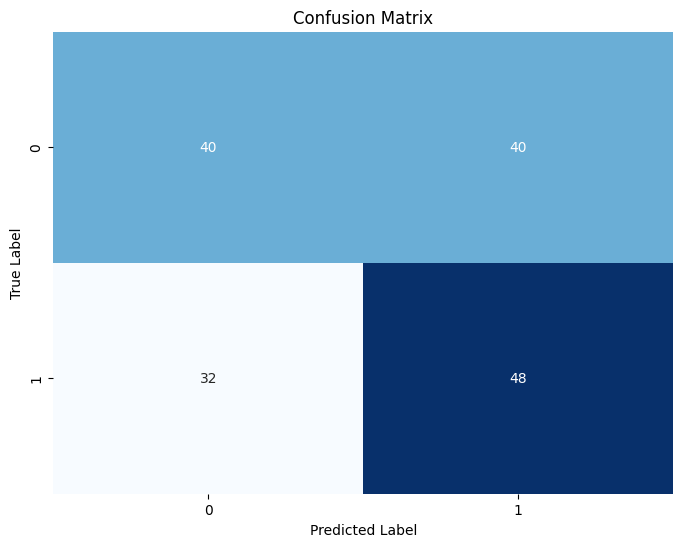

In [8]:
# Confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize = (8, 6))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues', cbar = False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title("Confusion Matrix")
plt.show()

In [10]:
# Group comparison
inf_test = test_df[test_df['account_type'] == 'influencer'] # Split test set
pol_test = test_df[test_df['account_type'] == 'politician']

print("Influencer test examples:", len(inf_test))
print("Politician test examples:", len(pol_test))

X_inf = vectorizer.transform(inf_test['clean_caption'])
y_inf = inf_test['label']

X_pol = vectorizer.transform(pol_test['clean_caption'])
y_pol = pol_test['label']

# Predict for each group
y_inf_pred = model.predict(X_inf)
y_pol_pred = model.predict(X_pol)

# Influencer performance
print("Influencer F1 Score:", f1_score(y_inf, y_inf_pred, average = 'macro'))
print("Influencer Accuracy:", accuracy_score(y_inf, y_inf_pred))

# Politician performance
print("Politician F1 Score:", f1_score(y_pol, y_pol_pred, average = 'macro'))
print("Politician Accuracy:", accuracy_score(y_pol, y_pol_pred))

Influencer test examples: 100
Politician test examples: 60
Influencer F1 Score: 0.48748869460355737
Influencer Accuracy: 0.49
Politician F1 Score: 0.6499027507641011
Politician Accuracy: 0.65


### 2) Fine-tuned BERT classifier

In [11]:
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import numpy as np
import torch
from sklearn.metrics import f1_score, accuracy_score
import matplotlib.pyplot

In [12]:
# Convert pandas dataset to HuggingFace Dataset
train_dataset = Dataset.from_pandas(train_df[['clean_caption', 'label']])
val_dataset = Dataset.from_pandas(val_df[['clean_caption', 'label']])
test_dataset = Dataset.from_pandas(test_df[['clean_caption', 'label']])

In [13]:
# BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize(example):
  return tokenizer(example['clean_caption'], paddings='max_length', truncation=True, max_length=150)

train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset = val_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Map:   0%|          | 0/560 [00:00<?, ? examples/s]

Map:   0%|          | 0/80 [00:00<?, ? examples/s]

Map:   0%|          | 0/160 [00:00<?, ? examples/s]

In [14]:
# Format for PyTorch
train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
val_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

# Load BERT model
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [15]:
# Defining the computation of the metrics
def compute_metrics(eval_pred):
  logits, labels = eval_pred
  preds = np.argmax(logits, axis=-1)
  return{
      'f1': f1_score(labels, preds, average='macro'),
      "accuracy": accuracy_score(labels, preds)
  }

In [19]:
# Training setup
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir='./results',
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    # evaluation_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="no"
)

from transformers import DataCollatorWithPadding

# Create a collator
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Adding a Trainer
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator, # dynamically pads each batch
    compute_metrics=compute_metrics
)

trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
70,0.682618
140,0.528013
210,0.363748


TrainOutput(global_step=210, training_loss=0.5247932979038783, metrics={'train_runtime': 1640.6694, 'train_samples_per_second': 1.024, 'train_steps_per_second': 0.128, 'total_flos': 85223315275200.0, 'train_loss': 0.5247932979038783, 'epoch': 3.0})

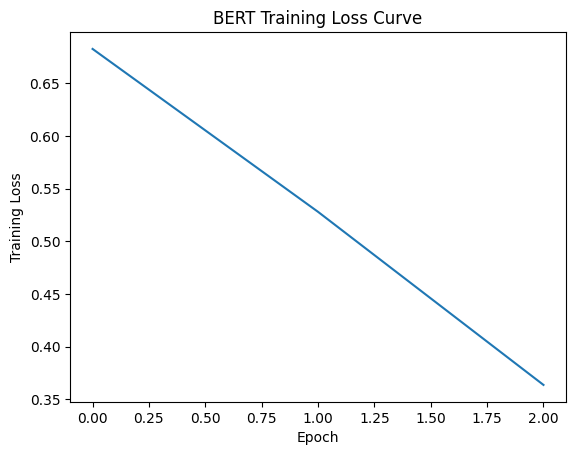

In [22]:
# Plot the loss curve
logs = trainer.state.log_history

train_losses = [log["loss"] for log in logs if "loss" in log]

plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("BERT Training Loss Curve")
plt.show()

In [27]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.63      0.80      0.70        80
           1       0.72      0.53      0.61        80

    accuracy                           0.66       160
   macro avg       0.68      0.66      0.66       160
weighted avg       0.68      0.66      0.66       160



In [29]:
# BERT Group Comparison
test_df = test_df.reset_index(drop=True)
test_df['pred'] = y_pred

inf = test_df[test_df['account_type'] == 'influencer']
pol = test_df[test_df['account_type'] == 'politician']

from sklearn.metrics import f1_score, accuracy_score

print("Influencer F1:", f1_score(inf['label'], inf['pred'], average='macro'))
print("Influencer Accuracy:", accuracy_score(inf['label'], inf['pred']))

print("Politician F1:", f1_score(pol['label'], pol['pred'], average='macro'))
print("Politician Accuracy:", accuracy_score(pol['label'], pol['pred']))

Influencer F1: 0.6175523349436394
Influencer Accuracy: 0.62
Politician F1: 0.717978848413631
Politician Accuracy: 0.7333333333333333
